# 📊 Telco Customer Churn Analysis & Prediction

**Objective:** Analyze customer churn patterns and build a high-performance ML model to predict whether a customer will churn.

**Dataset:** Telco Customer Churn (7,043 customers × 21 features)

---
## Table of Contents
1. Data Loading & Inspection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Comparison
6. Model Evaluation & Selection
7. Save Best Model


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 1. Data Loading & Inspection

In [6]:
# Load the dataset
df = pd.read_csv('Telco_Customer_Churn.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Total Customers: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
df.head(10)


Dataset Shape: (7043, 21)
Total Customers: 7,043
Total Features: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [7]:
# Data types and info
print("=" * 60)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 60)
df.info()


DATA TYPES & NON-NULL COUNTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

In [8]:
# Statistical summary
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No null values found")
print(f"\nTotal null values: {df.isnull().sum().sum()}")

# Check for blank strings (TotalCharges has spaces)
print(f"\nBlank strings in TotalCharges: {(df['TotalCharges'] == ' ').sum()}")
print(f"Rows with blank TotalCharges:")
df[df['TotalCharges'] == ' '][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


MISSING VALUES
No null values found

Total null values: 0

Blank strings in TotalCharges: 11
Rows with blank TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


## 2. Data Cleaning & Preprocessing

In [10]:
# Fix TotalCharges - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN TotalCharges with MonthlyCharges (these are tenure=0 customers)
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

# Drop customerID - not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# Convert SeniorCitizen to categorical labels for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("✅ Data cleaning complete!")
print(f"Final shape: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")


✅ Data cleaning complete!
Final shape: (7043, 20)
Remaining nulls: 0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

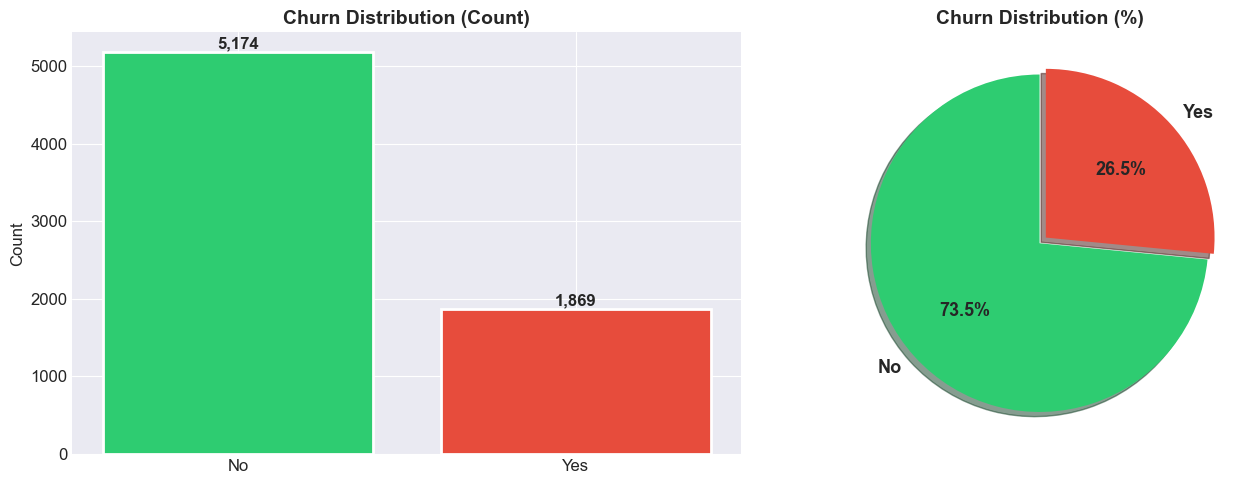


Churn Rate: 26.5%
Retained Rate: 73.5%


In [11]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 13, 'fontweight': 'bold'},
            shadow=True)
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nChurn Rate: {(df['Churn'] == 'Yes').mean():.1%}")
print(f"Retained Rate: {(df['Churn'] == 'No').mean():.1%}")


### 3.2 Numerical Features Analysis

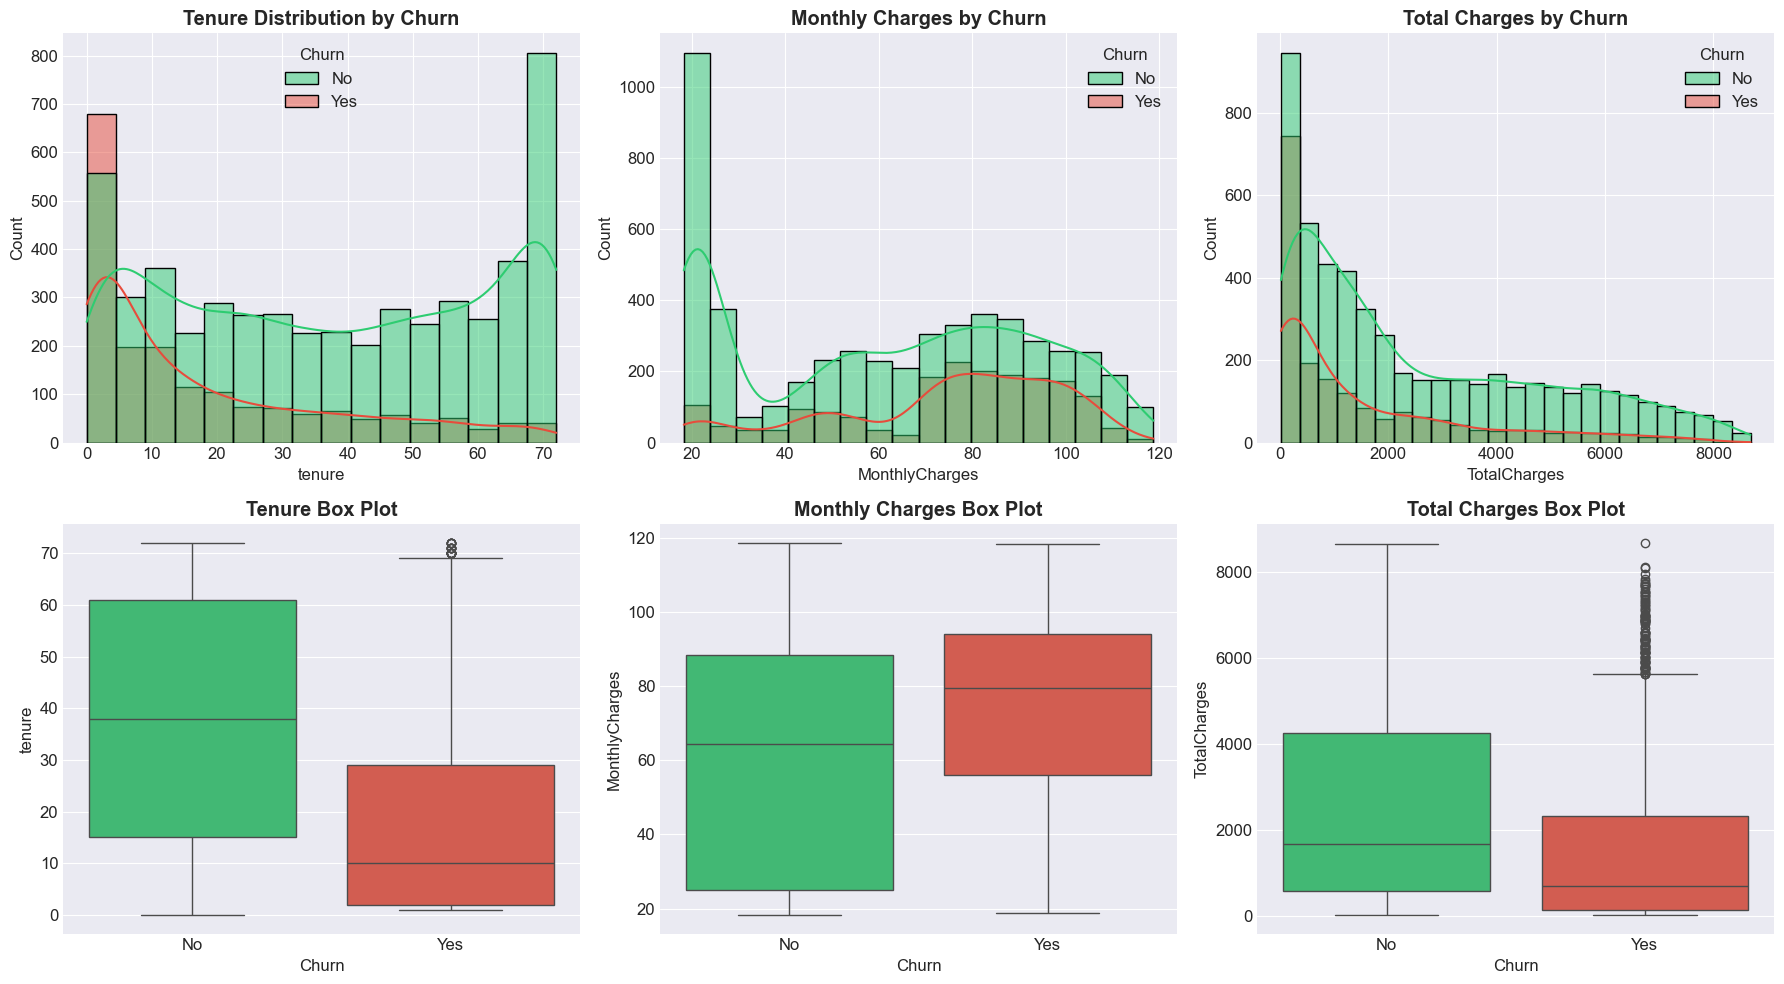

In [12]:
# Distribution of Numerical Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0, 0], palette=colors)
axes[0, 0].set_title('Tenure Distribution by Churn', fontweight='bold')

# Monthly Charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Monthly Charges by Churn', fontweight='bold')

# Total Charges distribution
sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[0, 2], palette=colors)
axes[0, 2].set_title('Total Charges by Churn', fontweight='bold')

# Box plots
sns.boxplot(data=df, x='Churn', y='tenure', palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('Tenure Box Plot', fontweight='bold')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=colors, ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges Box Plot', fontweight='bold')

sns.boxplot(data=df, x='Churn', y='TotalCharges', palette=colors, ax=axes[1, 2])
axes[1, 2].set_title('Total Charges Box Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('numerical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Categorical Features & Churn Rate

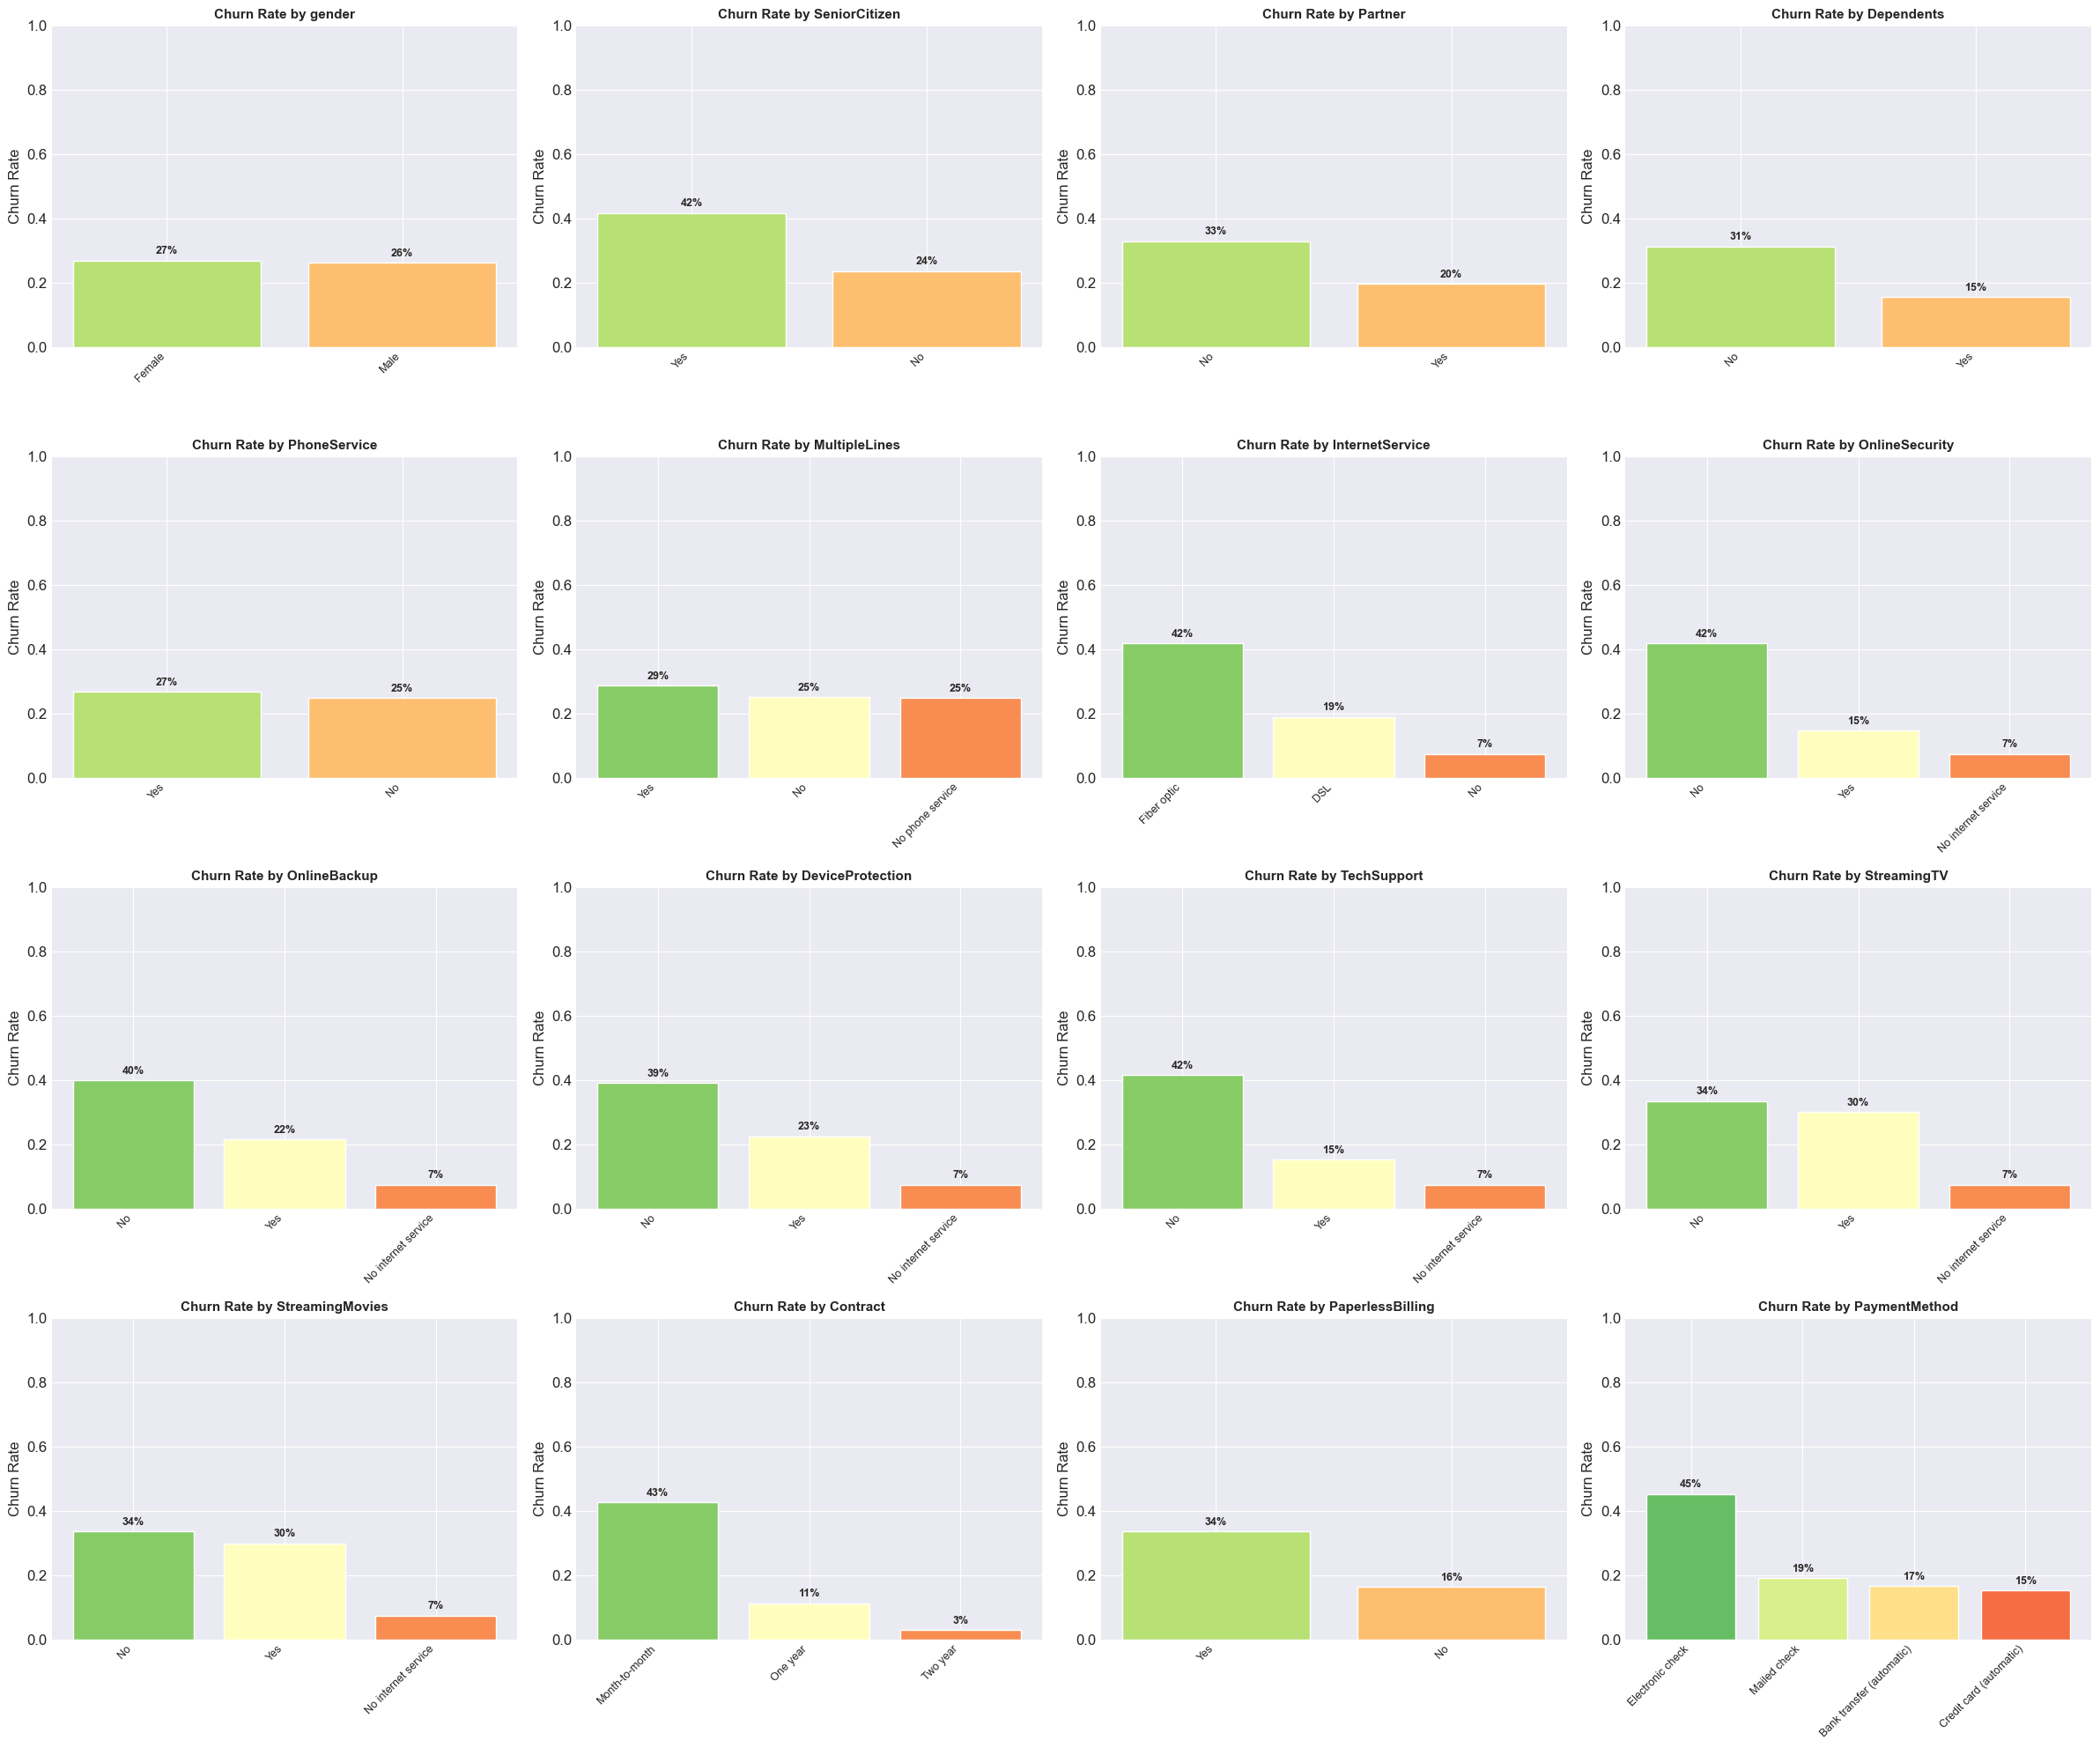

In [13]:
# Churn rate by categorical features
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values, 
                       color=sns.color_palette('RdYlGn_r', len(churn_rate)), edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=9)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 1)
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.02, f'{v:.0%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Correlation Heatmap

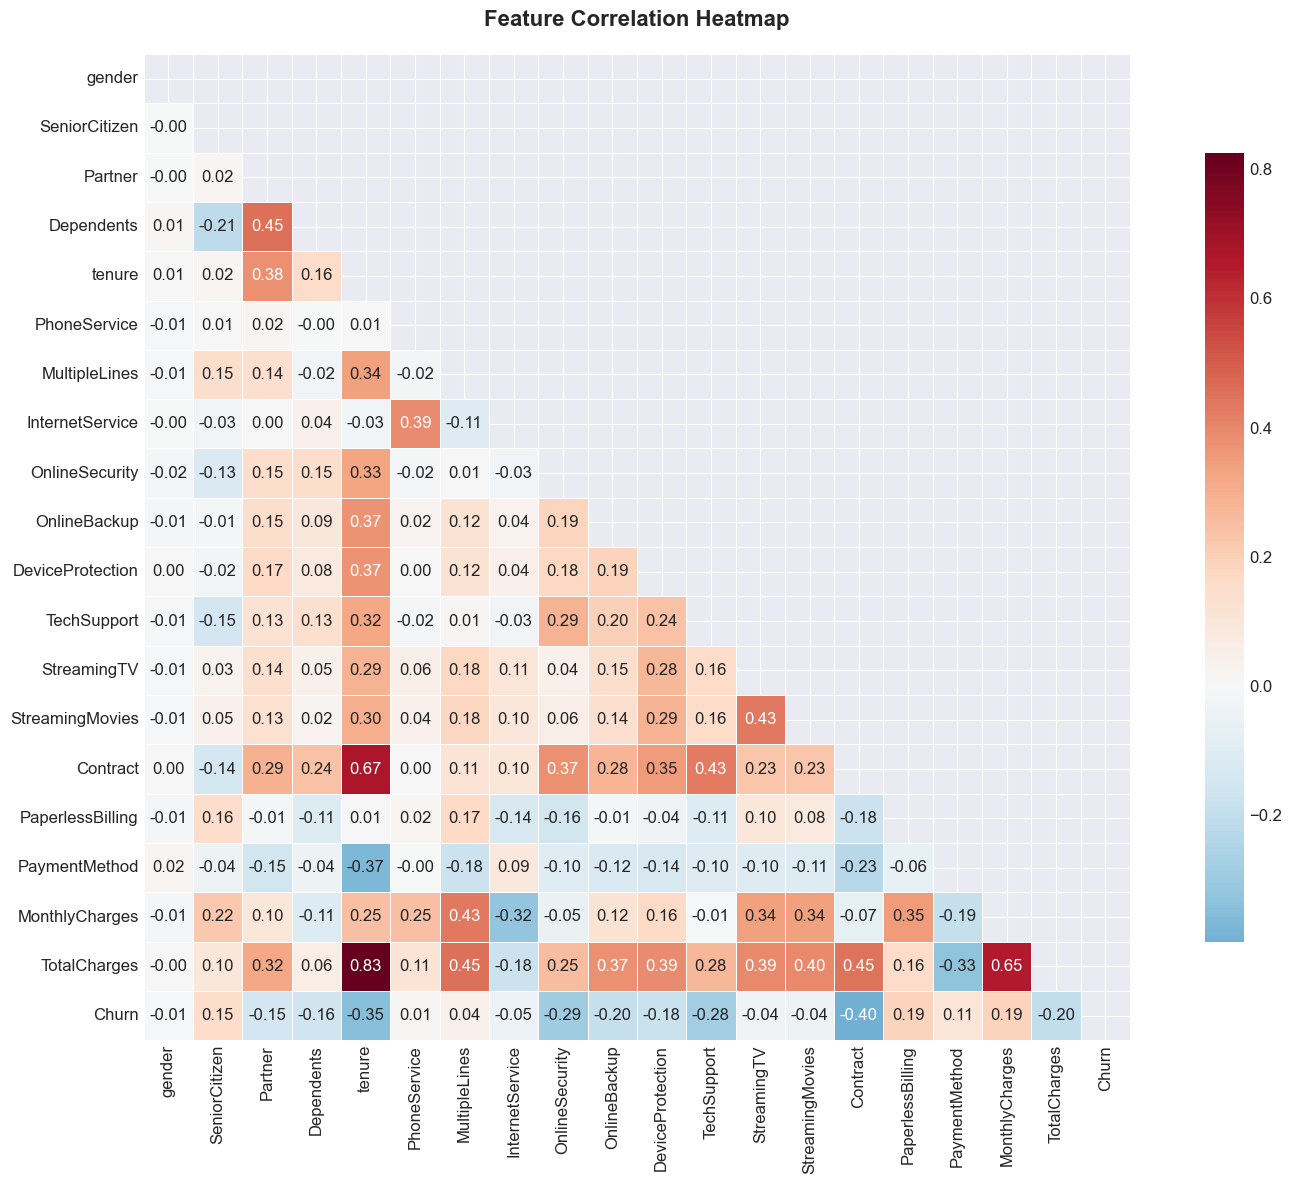


📊 Top Feature Correlations with Churn:
  Contract                  -0.397  ███████████
  tenure                    -0.352  ██████████
  OnlineSecurity            -0.289  ████████
  TechSupport               -0.282  ████████
  TotalCharges              -0.198  █████
  OnlineBackup              -0.196  █████
  MonthlyCharges            +0.193  █████
  PaperlessBilling          +0.192  █████
  DeviceProtection          -0.178  █████
  Dependents                -0.164  ████
  SeniorCitizen             +0.151  ████
  Partner                   -0.150  ████
  PaymentMethod             +0.107  ███
  InternetService           -0.047  █
  StreamingMovies           -0.038  █
  MultipleLines             +0.038  █
  StreamingTV               -0.037  █
  PhoneService              +0.012  
  gender                    -0.009  


In [14]:
# Encode for correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Correlation heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Churn
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("\n📊 Top Feature Correlations with Churn:")
print("=" * 45)
for feat, corr in churn_corr.items():
    bar = '█' * int(abs(corr) * 30)
    sign = '+' if corr > 0 else '-'
    print(f"  {feat:25s} {sign}{abs(corr):.3f}  {bar}")


### 3.5 Key Insights

In [15]:
# Key churn insights
print("=" * 60)
print("📋 KEY INSIGHTS FROM EDA")
print("=" * 60)
print()
print("1. 🔴 Churn Rate: ~26.5% — significant class imbalance")
print("2. 📅 Short tenure customers churn MORE (new customers at risk)")
print("3. 💰 Higher MonthlyCharges → Higher churn likelihood")
print("4. 📝 Month-to-month contracts have HIGHEST churn rate (~42%)")
print("5. 🌐 Fiber optic internet users churn more than DSL users")
print("6. 🛡️ Customers without OnlineSecurity/TechSupport churn more")
print("7. 💳 Electronic check payment → Highest churn rate")
print("8. 👴 Senior citizens churn more than non-seniors")
print("9. 👫 Customers without partners/dependents churn more")
print("10.📄 Paperless billing customers churn more")


📋 KEY INSIGHTS FROM EDA

1. 🔴 Churn Rate: ~26.5% — significant class imbalance
2. 📅 Short tenure customers churn MORE (new customers at risk)
3. 💰 Higher MonthlyCharges → Higher churn likelihood
4. 📝 Month-to-month contracts have HIGHEST churn rate (~42%)
5. 🌐 Fiber optic internet users churn more than DSL users
6. 🛡️ Customers without OnlineSecurity/TechSupport churn more
7. 💳 Electronic check payment → Highest churn rate
8. 👴 Senior citizens churn more than non-seniors
9. 👫 Customers without partners/dependents churn more
10.📄 Paperless billing customers churn more


## 4. Feature Engineering & Data Preparation

In [16]:
# Prepare features
df_model = df.copy()

# Encode target variable
df_model['Churn'] = df_model['Churn'].map({'No': 0, 'Yes': 1})

# One-hot encode categorical variables
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"\nShape after encoding: {df_model.shape}")
print(f"Features: {df_model.shape[1] - 1}")
df_model.head()


Categorical columns to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 31)
Features: 30


,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,1,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [17]:
# Split features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Save feature names for later use
feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nChurn ratio: {y.mean():.3f}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")


Number of features: 30
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn ratio: 0.265

Train set: 5634 samples
Test set:  1409 samples


In [18]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After SMOTE:  {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")
print("\n✅ Feature scaling and SMOTE complete!")


Before SMOTE: {np.int64(0): np.int64(4139), np.int64(1): np.int64(1495)}
After SMOTE:  {np.int64(0): np.int64(4139), np.int64(1): np.int64(4139)}

✅ Feature scaling and SMOTE complete!


## 5. Model Training & Comparison

In [19]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, 
                                             min_samples_split=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, 
                                                     learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              use_label_encoder=False, eval_metric='logloss',
                              random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

# Train and evaluate each model
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 80)
print("MODEL TRAINING & EVALUATION")
print("=" * 80)

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
    
    results[name] = {
        'model': model,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  ✅ Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"     F1-Score: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print(f"     CV ROC-AUC: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

print("\n" + "=" * 80)
print("✅ All models trained successfully!")


MODEL TRAINING & EVALUATION

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.7381 | Precision: 0.5042 | Recall: 0.7968
     F1-Score: 0.6176 | ROC-AUC: 0.8405
     CV ROC-AUC: 0.8549 (±0.0020)

🔄 Training Random Forest...
  ✅ Accuracy: 0.7665 | Precision: 0.5455 | Recall: 0.7219
     F1-Score: 0.6214 | ROC-AUC: 0.8405
     CV ROC-AUC: 0.9060 (±0.0048)

🔄 Training Gradient Boosting...
  ✅ Accuracy: 0.7736 | Precision: 0.5700 | Recall: 0.5989
     F1-Score: 0.5841 | ROC-AUC: 0.8265
     CV ROC-AUC: 0.9346 (±0.0036)

🔄 Training XGBoost...
  ✅ Accuracy: 0.7757 | Precision: 0.5721 | Recall: 0.6150
     F1-Score: 0.5928 | ROC-AUC: 0.8322
     CV ROC-AUC: 0.9353 (±0.0046)

🔄 Training SVM...
  ✅ Accuracy: 0.7573 | Precision: 0.5316 | Recall: 0.7193
     F1-Score: 0.6114 | ROC-AUC: 0.8164
     CV ROC-AUC: 0.8900 (±0.0030)

✅ All models trained successfully!


## 6. Model Evaluation & Selection

### 6.1 Performance Comparison

In [20]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1_score'],
        'ROC-AUC': r['roc_auc'],
        'CV ROC-AUC': r['cv_mean']
    } for name, r in results.items()
}).T

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print("\n📊 MODEL PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string())

# Highlight best model
best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']:.4f})")



📊 MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC  CV ROC-AUC
Logistic Regression  0.738112   0.504230  0.796791  0.617617  0.840505    0.854910
Random Forest        0.766501   0.545455  0.721925  0.621404  0.840462    0.906045
XGBoost              0.775727   0.572139  0.614973  0.592784  0.832243    0.935315
Gradient Boosting    0.773598   0.569975  0.598930  0.584094  0.826454    0.934559
SVM                  0.757275   0.531621  0.719251  0.611364  0.816410    0.890019

🏆 Best Model: Logistic Regression (ROC-AUC: 0.8405)


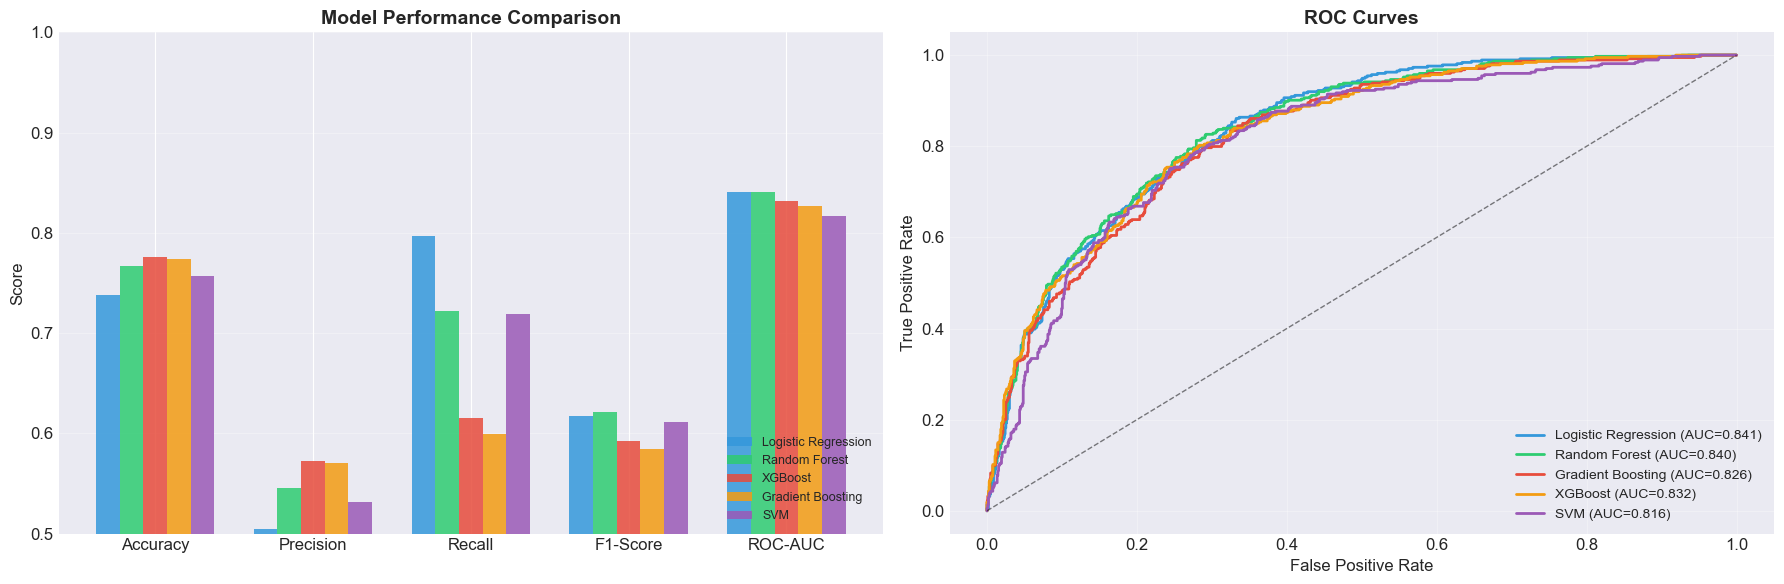

In [21]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (name, row) in enumerate(comparison_df.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics], width, 
                label=name, color=colors_models[i], alpha=0.85)

axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# ROC Curves
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_pred_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", 
                 color=colors_models[i], linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Best Model — Detailed Analysis

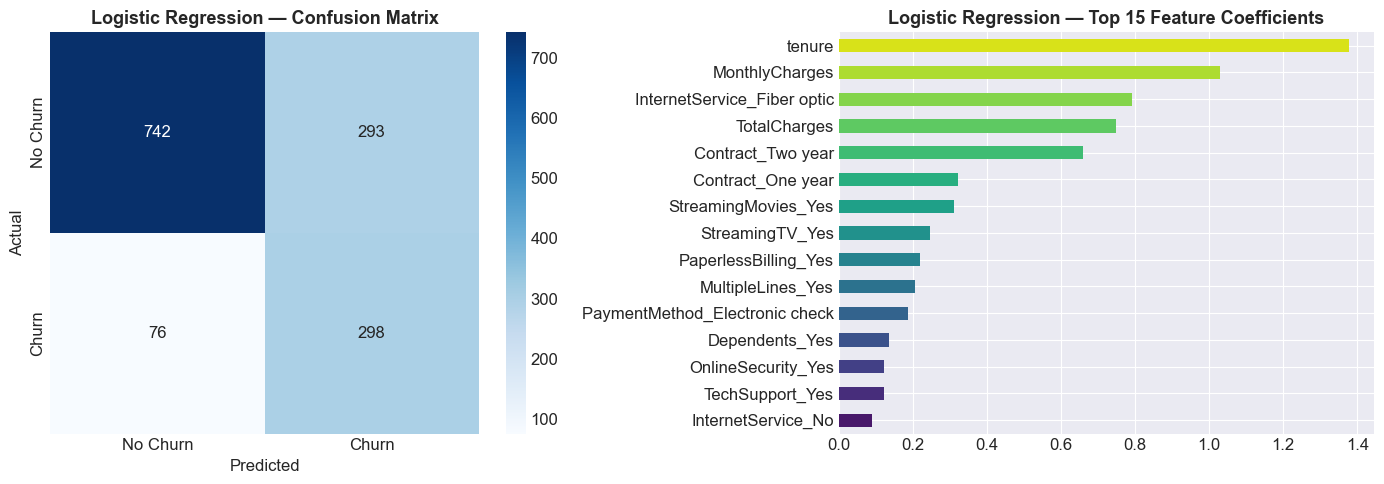


📋 Classification Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [22]:
# Best model confusion matrix & classification report
best_result = results[best_model_name]
y_pred_best = best_result['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'{best_model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance (if available)
if hasattr(best_result['model'], 'feature_importances_'):
    importances = best_result['model'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(15)
    feat_imp.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', 15))
    axes[1].set_title(f'{best_model_name} — Top 15 Feature Importances', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Importance')
else:
    # Use coefficients for linear models
    coefs = np.abs(best_result['model'].coef_[0])
    feat_imp = pd.Series(coefs, index=feature_names).sort_values(ascending=True).tail(15)
    feat_imp.plot(kind='barh', ax=axes[1], color=sns.color_palette('viridis', 15))
    axes[1].set_title(f'{best_model_name} — Top 15 Feature Coefficients', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📋 Classification Report — {best_model_name}")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


## 7. Save Best Model & Pipeline

In [23]:
# Save the best model, scaler, and feature names
best_model = best_result['model']

# Save model
joblib.dump(best_model, 'churn_model.pkl')
print(f"✅ Best model ({best_model_name}) saved as 'churn_model.pkl'")

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

# Save feature names and column info for frontend
pipeline_info = {
    'feature_names': feature_names,
    'best_model_name': best_model_name,
    'accuracy': best_result['accuracy'],
    'roc_auc': best_result['roc_auc'],
    'f1_score': best_result['f1_score']
}
joblib.dump(pipeline_info, 'pipeline_info.pkl')
print("✅ Pipeline info saved as 'pipeline_info.pkl'")

print(f"\n🏆 Final Model Performance:")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")
print(f"   ROC-AUC: {best_result['roc_auc']:.4f}")
print(f"   F1-Score: {best_result['f1_score']:.4f}")
print(f"\n✅ All artifacts saved! Ready for deployment.")


✅ Best model (Logistic Regression) saved as 'churn_model.pkl'
✅ Scaler saved as 'scaler.pkl'
✅ Pipeline info saved as 'pipeline_info.pkl'

🏆 Final Model Performance:
   Model: Logistic Regression
   Accuracy: 0.7381
   ROC-AUC: 0.8405
   F1-Score: 0.6176

✅ All artifacts saved! Ready for deployment.


In [24]:
# Save feature importances for the frontend visualization
if hasattr(best_model, 'feature_importances_'):
    importances_dict = dict(zip(feature_names, best_model.feature_importances_.tolist()))
else:
    importances_dict = dict(zip(feature_names, np.abs(best_model.coef_[0]).tolist()))

import json
with open('feature_importances.json', 'w') as f:
    json.dump(importances_dict, f, indent=2)
print("✅ Feature importances saved as 'feature_importances.json'")


✅ Feature importances saved as 'feature_importances.json'
